# Edge IIoT – Data Cleaning Pipeline

Column-level documentation and treatment decisions: [docs/preliminary.md](../../docs/preliminary.md)

## 0 - Setup

In [48]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import ipaddress
from urllib.parse import urlparse

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from src.config import DATASETS

dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Raw path:       {config['raw_path']}")
print(f"Processed path: {config['processed_path']}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Dataset Information ---
Name: EDGE_IIOT
Raw path:       /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/raw
Processed path: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/processed


In [49]:
def load_csv(filename: str) -> pd.DataFrame:
    csv_path = (
        config['raw_path']
        / "Edge-IIoTset dataset"
        / "Selected dataset for ML and DL"
        / f"{filename}.csv"
    )
    print(f"Loading: {csv_path}")
    df = pd.read_csv(csv_path, low_memory=False)
    print(f"Shape: {df.shape}")
    return df


In [50]:
# ── Helpers ────────────────────────────────────────────────────────────────
def print_unique_values(df, column_names):
    for col in column_names:
        print(f"\n--- {col} ---\n{df[col].unique()}\n")

def find_packet_type_columns(df, packet_type):
    return [col for col in df.columns if col.startswith(f'{packet_type}.')]


---
## 1 - Building the Cleaning Pipeline


### 1.1 - Protocol Labeller

Assigns a human-readable `proto` column (ARP, ICMP, TCP, UDP, HTTP, DNS, MQTT, MBTCP) and removes rows that cannot be attributed to any known protocol.


In [51]:
class ProtocolLabeller(BaseEstimator, TransformerMixin):
    """Derive the proto column and drop unidentifiable rows."""

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()
        df['proto'] = 'noinfo'

        df.loc[df['arp.opcode'] != 0, 'proto'] = 'ARP'
        df.loc[
            (df['icmp.checksum'] != 0) |
            (df['icmp.seq_le'] != 0) |
            (df['icmp.transmit_timestamp'] != 0),
            'proto'
        ] = 'ICMP'
        df.loc[
            (~df['tcp.srcport'].isin(['0.0', '0'])) |
            (~df['tcp.dstport'].isin(['0.0', '0'])),
            'proto'
        ] = 'TCP'
        df.loc[df['udp.port'] != 0, 'proto'] = 'UDP'
        df.loc[~df['http.request.method'].isin(['0.0', '0']), 'proto'] = 'HTTP'
        df.loc[df['dns.qry.qu'] != 0, 'proto'] = 'DNS'
        df.loc[df['mqtt.msgtype'] != 0, 'proto'] = 'MQTT'
        df.loc[
            (df['tcp.srcport'] == 502) | (df['tcp.dstport'] == 502),
            'proto'
        ] = 'MBTCP'

        before = len(df)
        df = df[df['proto'] != 'noinfo'].copy()
        
        if before - len(df) != 0:
            raise Exception(f"[Protocol] Error. {before - len(df)} unidentifiable rows.")

        print(f"[Protocol] Summary")
        print(df['proto'].value_counts().to_string())
        return df


### 1.2 - Frame Transformer

* Parses `frame.time` and flags invalid timestamps as `frame.time.valid`
* Sorts by `frame.time`; (invalid at the end).
* New per flow features based on src and dst IPs and protocol.
    * `frame.time.order` (sequence number)
    * `frame.time.delta` (inter-packet gap in seconds).
* Drops the raw `frame.time` column.


In [52]:
class FrameTransformer(BaseEstimator, TransformerMixin):
    """Handle frame.* columns."""

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()
        flow_cols = ['ip.src_host', 'ip.dst_host', 'proto']

        # Parse timestamps
        df['frame.time'] = df['frame.time'].str.strip()
        converted = pd.to_datetime(
            df['frame.time'], format="%Y %H:%M:%S.%f", exact=False, errors='coerce'
        )
        noisy = converted.isna().sum()
        print(f"[Frame] Noisy frame.time rows: {noisy} ({noisy/len(df)*100:.4f}%)")

        # Flag invalid timestamps
        df['frame.time.valid'] = (~converted.isna()).astype(int)
        df['frame.time'] = converted

        # Sort valid rows by timestamp, append invalid rows at the end
        valid_mask = df['frame.time'].notna()
        df = pd.concat([
            df[valid_mask].sort_values('frame.time'),
            df[~valid_mask]
        ]).reset_index(drop=True)

        # Per-flow sequence number
        df['frame.time.order'] = df.groupby(flow_cols).cumcount() + 1

        # Inter-packet gap (NaT diff produces NaT, filled with 0)
        df['frame.time.delta'] = (
            df.groupby(flow_cols)['frame.time']
            .diff()
            .dt.total_seconds()
            .fillna(0)
        )

        df.drop(columns=['frame.time'], inplace=True)
        return df

### 1.3 - IP Transformer

* Categorises source and destination IPs as Private / Public / Reserved / Malformed.  
* One-hot-encodes both category columns.  
* Drops the raw IP address columns.


In [53]:
class IPTransformer(BaseEstimator, TransformerMixin):
    """Encode IP addresses as categorical features."""

    @staticmethod
    def _categorize(ip_str):
        try:
            if ip_str in ['0', '0.0', 0]:
                return 'Malformed'
            ip = ipaddress.ip_address(ip_str)
            if ip.is_private:
                return 'Private'
            elif ip.is_multicast or ip.is_reserved:
                return 'Reserved'
            return 'Public'
        except ValueError:
            return 'Invalid'

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()
        df['ip.src_category'] = df['ip.src_host'].apply(self._categorize)
        df['ip.dst_category'] = df['ip.dst_host'].apply(self._categorize)
        df = pd.get_dummies(df, columns=['ip.src_category', 'ip.dst_category'], dtype=int)
        df.drop(columns=['ip.src_host', 'ip.dst_host'], inplace=True)
        print("[IP] One-hot-encoded src/dst categories; dropped raw IP columns.")
        return df


### 1.4 - ARP Transformer

* Drops redundant address columns (`arp.dst.proto_ipv4`, `arp.src.proto_ipv4`) and constant `arp.hw.size`.  
* Splits `arp.opcode` into two binary flags: `arp.opcode_request` and `arp.opcode_reply`.


In [54]:
class ARPTransformer(BaseEstimator, TransformerMixin):
    """Clean ARP columns."""

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()
        drop_cols = ['arp.dst.proto_ipv4', 'arp.src.proto_ipv4', 'arp.hw.size']
        df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

        df['arp.opcode_request'] = (df['arp.opcode'] == 1).astype(int)
        df['arp.opcode_reply']   = (df['arp.opcode'] == 2).astype(int)
        df.drop(columns=['arp.opcode'], inplace=True)
        print("[ARP] Encoded opcode flags; dropped address/size columns.")
        return df


### 1.5 - ICMP Transformer

Drops `icmp.checksum` (raw integrity value), `icmp.transmit_timestamp` (always 0 outside attacks), and `icmp.unused`.


In [55]:
class ICMPTransformer(BaseEstimator, TransformerMixin):
    """Drop redundant ICMP columns."""

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()
        drop_cols = ['icmp.checksum', 'icmp.transmit_timestamp', 'icmp.unused']
        dropped = [c for c in drop_cols if c in df.columns]
        df.drop(columns=dropped, inplace=True)
        print(f"[ICMP] Dropped: {dropped}")
        return df


### 1.6 - HTTP Transformer

* Replaces `'0'`/`'0.0'` sentinels with empty strings in free-text fields.  
* Extracts URL path from `http.request.full_uri` → `http.request.path`, then drops the original column.  
* One-hot-encodes `http.request.method` for each method present in data.


In [56]:
class HTTPTransformer(BaseEstimator, TransformerMixin):
    """Clean and encode HTTP columns."""

    HTTP_METHODS = [
        'GET', 'HEAD', 'POST', 'PUT', 'DELETE',
        'CONNECT', 'OPTIONS', 'TRACE', 'PATCH',
        'PROPFIND', 'SEARCH'
    ]

    def fit(self, X, y=None):
        # Record which methods are actually present so transform is consistent
        self.active_methods_ = [
            m for m in self.HTTP_METHODS
            if (X['http.request.method'] == m).any()
        ]
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()
        sentinel = ['0', '0.0']

        for col in ['http.file_data', 'http.request.uri.query',
                    'http.referer', 'http.request.version']:
            if col in df.columns:
                df[col] = df[col].replace(sentinel, '')

        # Extract URL path
        def _path(uri):
            try:
                return urlparse(uri).path
            except Exception:
                return ''

        df['http.request.path'] = df['http.request.full_uri'].apply(_path)
        df['http.request.path'] = df['http.request.path'].replace(sentinel, '')
        df.drop(columns=['http.request.full_uri'], inplace=True)

        # Encode methods
        for method in self.active_methods_:
            col_name = f"http.request.method_{method.lower()}"
            df[col_name] = (df['http.request.method'] == method).astype(int)
        df.drop(columns=['http.request.method'], inplace=True)

        print(f"[HTTP] Encoded methods: {self.active_methods_}")
        return df


### 1.7 - TCP Transformer

* Drops redundant columns: `tcp.ack_raw`, port columns, `tcp.options`, `tcp.payload`.  
* Derives `tcp.nullchecksum` flag from `tcp.checksum`, then drops it.  
* Expands `tcp.flags` bitmask into 10 individual flag columns.  
* Drops redundant high-level flag columns (`tcp.connection.*`, `tcp.flags.ack`) already captured by the bitmask.


In [57]:
class TCPTransformer(BaseEstimator, TransformerMixin):
    """Clean and expand TCP columns."""

    FLAGS_MAP = {
        'tcp.flag.res': 0x200,
        'tcp.flag.ns':  0x100,
        'tcp.flag.cwr': 0x080,
        'tcp.flag.ece': 0x040,
        'tcp.flag.urg': 0x020,
        'tcp.flag.ack': 0x010,
        'tcp.flag.psh': 0x008,
        'tcp.flag.rst': 0x004,
        'tcp.flag.syn': 0x002,
        'tcp.flag.fin': 0x001,
    }

    REDUNDANT_CONN_COLS = [
        'tcp.connection.fin', 'tcp.connection.rst', 'tcp.connection.syn',
        'tcp.connection.synack', 'tcp.flags.ack'
    ]

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()

        # Null-checksum flag
        if 'tcp.checksum' in df.columns:
            df['tcp.nullchecksum'] = (df['tcp.checksum'] == '0').astype(int)
            df.drop(columns=['tcp.checksum'], inplace=True)

        # Drop ports, raw ack, options, payload
        drop_always = ['tcp.ack_raw', 'tcp.srcport', 'tcp.dstport',
                       'tcp.options', 'tcp.payload']
        df.drop(columns=[c for c in drop_always if c in df.columns], inplace=True)

        # Expand flags bitmask
        if 'tcp.flags' in df.columns:
            df['tcp.flags'] = df['tcp.flags'].astype(int)
            for flag_name, mask in self.FLAGS_MAP.items():
                df[flag_name] = (df['tcp.flags'] & mask).gt(0).astype('uint8')
            df.drop(columns=['tcp.flags'], inplace=True)

        # Drop redundant high-level connection columns
        df.drop(columns=[c for c in self.REDUNDANT_CONN_COLS if c in df.columns],
                inplace=True)

        print("[TCP] Expanded flags bitmask; dropped redundant columns.")
        return df


### 1.8 - UDP Transformer

Drops the combined `udp.port` column (individual port info is already captured via protocol labelling).


In [58]:
class UDPTransformer(BaseEstimator, TransformerMixin):
    """Clean UDP columns."""

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()
        if 'udp.port' in df.columns:
            df.drop(columns=['udp.port'], inplace=True)
            print("[UDP] Dropped udp.port.")
        return df


### 1.9 - DNS Transformer

Drops query name/type columns that leak ground-truth label information (`dns.qry.name`, `dns.qry.name.len`, `dns.qry.qu`, `dns.qry.type`).  
Keeps retransmission features which are predictive.


In [59]:
class DNSTransformer(BaseEstimator, TransformerMixin):
    """Drop leaky DNS query columns."""

    LEAKY = ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type']

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()
        drop = [c for c in self.LEAKY if c in df.columns]
        df.drop(columns=drop, inplace=True)
        print(f"[DNS] Dropped leaky query columns: {drop}")
        return df


### 1.10 - MQTT Transformer

* Cleans `mqtt.conack.flags` (mixed sentinel strings → numeric).  
* Drops `mqtt.conflags` (highly correlated with `mqtt.conflag.cleansess`).  
* Drops `mqtt.msg_decoded_as`, `mqtt.hdrflags` (redundant w/ msgtype), `mqtt.proto_len`, `mqtt.protoname`, `mqtt.topic`, `mqtt.topic_len`, `mqtt.ver`.  
* Replaces string sentinels in `mqtt.msg`.  
* One-hot-encodes `mqtt.msgtype`.


In [60]:
class MQTTTransformer(BaseEstimator, TransformerMixin):
    """Clean and encode MQTT columns."""

    MQTT_TYPES = {
        1: 'mqtt.msgtype_connect',    2: 'mqtt.msgtype_connack',
        3: 'mqtt.msgtype_publish',    4: 'mqtt.msgtype_puback',
        5: 'mqtt.msgtype_pubrec',     6: 'mqtt.msgtype_pubrel',
        7: 'mqtt.msgtype_pubcomp',    8: 'mqtt.msgtype_subscribe',
        9: 'mqtt.msgtype_suback',    10: 'mqtt.msgtype_unsubscribe',
       11: 'mqtt.msgtype_unsuback',  12: 'mqtt.msgtype_pingreq',
       13: 'mqtt.msgtype_pingresp',  14: 'mqtt.msgtype_disconnect',
    }

    DROP_COLS = [
        'mqtt.conflags', 'mqtt.msg_decoded_as', 'mqtt.hdrflags',
        'mqtt.proto_len', 'mqtt.protoname', 'mqtt.topic',
        'mqtt.topic_len', 'mqtt.ver',
    ]

    def fit(self, X, y=None):
        self.active_types_ = [
            code for code, _ in self.MQTT_TYPES.items()
            if (X['mqtt.msgtype'] == code).any()
        ]
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()

        # Fix conack.flags mixed types
        if 'mqtt.conack.flags' in df.columns:
            df['mqtt.conack.flags'] = (
                df['mqtt.conack.flags']
                .replace(['0', '0.0', '0x00000000'], '0')
            )
            df['mqtt.conack.flags'] = pd.to_numeric(
                df['mqtt.conack.flags']
            ).astype(int)

        # Clean mqtt.msg sentinels
        if 'mqtt.msg' in df.columns:
            df['mqtt.msg'] = df['mqtt.msg'].replace(['0', '0.0'], '')

        # Drop redundant columns
        df.drop(columns=[c for c in self.DROP_COLS if c in df.columns], inplace=True)

        # One-hot encode msgtype
        if 'mqtt.msgtype' in df.columns:
            for code in self.active_types_:
                col_name = self.MQTT_TYPES[code]
                df[col_name] = (df['mqtt.msgtype'] == code).astype(int)
            df.drop(columns=['mqtt.msgtype'], inplace=True)

        print(f"[MQTT] Encoded {len(self.active_types_)} message types.")
        return df


### 1.11 - Post-processing Transformer

* Removes duplicate rows (keeping first occurrence).  
* Prints final column count and class distribution.


In [61]:
class PostProcessor(BaseEstimator, TransformerMixin):
    """Deduplication and final reporting."""

    def fit(self, X, y=None):
        return self

    def __sklearn_is_fitted__(self):
        return True

    def transform(self, X):
        df = X.copy()
        before = len(df)
        df = df.drop_duplicates(keep='first')
        removed = before - len(df)
        pct = removed / before * 100
        print(f"[Post] Removed {removed} duplicates ({pct:.2f}%).")
        print(f"[Post] Final shape: {df.shape}")
        print(f"[Post] Columns ({len(df.columns)}):\n  {list(df.columns)}")
        return df


### 1.12 - Assembling the Pipeline

All transformers are chained via `sklearn.pipeline.Pipeline`.

* **`fit_transform(df_ml_raw)`** — fits each transformer on the ML dataset (recording active HTTP methods and MQTT message types) and transforms it.  
* **`transform(df_dnn_raw)`** — reuses the fitted state to transform the DNN dataset with the same column schema.  

Each transformer implements `__sklearn_is_fitted__` so `Pipeline.transform()` recognises the pipeline as ready after `fit_transform`.


In [62]:
cleaning_pipeline = Pipeline(steps=[
    ('protocol_labeller', ProtocolLabeller()),
    ('frame',             FrameTransformer()),
    ('ip',                IPTransformer()),
    ('arp',               ARPTransformer()),
    ('icmp',              ICMPTransformer()),
    ('http',              HTTPTransformer()),
    ('tcp',               TCPTransformer()),
    ('udp',               UDPTransformer()),
    ('dns',               DNSTransformer()),
    ('mqtt',              MQTTTransformer()),
    ('post',              PostProcessor()),
])

cleaning_pipeline_sort = Pipeline(steps=[
    ('protocol_labeller', ProtocolLabeller()),
    ('frame',             FrameTransformer()),
    ('ip',                IPTransformer()),
    ('arp',               ARPTransformer()),
    ('icmp',              ICMPTransformer()),
    ('http',              HTTPTransformer()),
    ('tcp',               TCPTransformer()),
    ('udp',               UDPTransformer()),
    ('dns',               DNSTransformer()),
    ('mqtt',              MQTTTransformer()),
    ('post',              PostProcessor()),
])

print("Pipeline assembled:")
for name, step in cleaning_pipeline.steps:
    print(f"  {name:25s} → {step.__class__.__name__}")


Pipeline assembled:
  protocol_labeller         → ProtocolLabeller
  frame                     → FrameTransformer
  ip                        → IPTransformer
  arp                       → ARPTransformer
  icmp                      → ICMPTransformer
  http                      → HTTPTransformer
  tcp                       → TCPTransformer
  udp                       → UDPTransformer
  dns                       → DNSTransformer
  mqtt                      → MQTTTransformer
  post                      → PostProcessor


---
## 2 - Applying the Pipeline to Both Datasets



In [63]:
# ── Load both datasets ───────────────────────────────────────────────────────
print("=" * 60)
print("Loading ML dataset …")
df_ml_raw = load_csv("ML-EdgeIIoT-dataset")

print("\nLoading DNN dataset …")
df_dnn_raw = load_csv("DNN-EdgeIIoT-dataset")


Loading ML dataset …
Loading: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/ML-EdgeIIoT-dataset.csv
Shape: (157800, 63)

Loading DNN dataset …
Loading: /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/raw/Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv
Shape: (2219201, 63)


In [64]:
# ── Apply Pipeline ML ────────────────────────────────────────────────
print("=" * 60)
print("ML dataset")
print("=" * 60)
df_ml = cleaning_pipeline.fit_transform(df_ml_raw)


ML dataset
[Protocol] Summary
proto
TCP      145117
HTTP       7196
MQTT       5063
DNS         256
UDP         149
MBTCP        19
[Frame] Noisy frame.time rows: 15712 (9.9569%)
[IP] One-hot-encoded src/dst categories; dropped raw IP columns.
[ARP] Encoded opcode flags; dropped address/size columns.
[ICMP] Dropped: ['icmp.checksum', 'icmp.transmit_timestamp', 'icmp.unused']
[HTTP] Encoded methods: ['GET', 'POST', 'OPTIONS', 'TRACE']
[TCP] Expanded flags bitmask; dropped redundant columns.
[UDP] Dropped udp.port.
[DNS] Dropped leaky query columns: ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type']
[MQTT] Encoded 4 message types.
[Post] Removed 5209 duplicates (3.30%).
[Post] Final shape: (152591, 59)
[Post] Columns (59):
  ['icmp.seq_le', 'http.file_data', 'http.content_length', 'http.request.uri.query', 'http.referer', 'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack', 'tcp.len', 'tcp.seq', 'udp.stream', 'udp.time_delta', 'dns.retransmission', 'dns.re

In [65]:
# ── Apply Pipeline DL ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("DNN dataset")
print("=" * 60)
df_dnn = cleaning_pipeline_sort.fit_transform(df_dnn_raw)


DNN dataset
[Protocol] Summary
proto
TCP      1851503
MQTT      332083
HTTP       32087
DNS         2072
MBTCP        934
UDP          522
[Frame] Noisy frame.time rows: 122782 (5.5327%)
[IP] One-hot-encoded src/dst categories; dropped raw IP columns.
[ARP] Encoded opcode flags; dropped address/size columns.
[ICMP] Dropped: ['icmp.checksum', 'icmp.transmit_timestamp', 'icmp.unused']
[HTTP] Encoded methods: ['GET', 'POST', 'PUT', 'OPTIONS', 'TRACE', 'PROPFIND', 'SEARCH']
[TCP] Expanded flags bitmask; dropped redundant columns.
[UDP] Dropped udp.port.
[DNS] Dropped leaky query columns: ['dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu', 'dns.qry.type']
[MQTT] Encoded 4 message types.
[Post] Removed 60451 duplicates (2.72%).
[Post] Final shape: (2158750, 62)
[Post] Columns (62):
  ['icmp.seq_le', 'http.file_data', 'http.content_length', 'http.request.uri.query', 'http.referer', 'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack', 'tcp.len', 'tcp.seq', 'udp.stream', 'udp.ti

In [66]:
# ── Sanity check: column alignment ───────────────────────────────────────────
ml_cols  = set(df_ml.columns)
dnn_cols = set(df_dnn.columns)

only_ml  = ml_cols  - dnn_cols
only_dnn = dnn_cols - ml_cols

print(f"ML  columns: {len(ml_cols)}")
print(f"DNN columns: {len(dnn_cols)}")

if only_ml:
    print(f"\nOnly in ML  (will be 0-filled in DNN): {sorted(only_ml)}")
if only_dnn:
    print(f"Only in DNN (will be 0-filled in ML):  {sorted(only_dnn)}")

if not only_ml and not only_dnn:
    print("\n✓ Column sets are identical.")


ML  columns: 59
DNN columns: 62
Only in DNN (will be 0-filled in ML):  ['http.request.method_propfind', 'http.request.method_put', 'http.request.method_search']


In [67]:
# Align columns (fill missing with 0) so both dataframes share the same schema
all_cols = sorted(ml_cols | dnn_cols)
df_ml  = df_ml.reindex(columns=all_cols,  fill_value=0)
df_dnn = df_dnn.reindex(columns=all_cols, fill_value=0)

print(f"Aligned shape → ML: {df_ml.shape}, DNN: {df_dnn.shape}")


Aligned shape → ML: (152591, 62), DNN: (2158750, 62)


---
## 3 - Class Distribution After Cleaning


In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_label_distribution(df_data, label_col, title_suffix=""):
    conteo = df_data[label_col].value_counts()
    labels, sizes = conteo.index, conteo.values
    palette = sns.color_palette("viridis", len(labels))
    color_map = dict(zip(labels, palette))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Attack distribution – {title_suffix}", fontsize=13)

    sns.countplot(y=label_col, data=df_data, ax=ax1,
                  order=labels, hue=label_col,
                  palette=color_map, legend=False)
    ax1.set_title(f"Count per {label_col}")

    ax2.pie(sizes, explode=[0.05]*len(labels), labels=labels,
            autopct='%1.1f%%', startangle=60, pctdistance=0.85,
            colors=[color_map[l] for l in labels])
    ax2.add_artist(plt.Circle((0, 0), 0.70, fc='white'))
    ax2.set_title(f"Proportion per {label_col}")

    plt.tight_layout()
    plt.show()


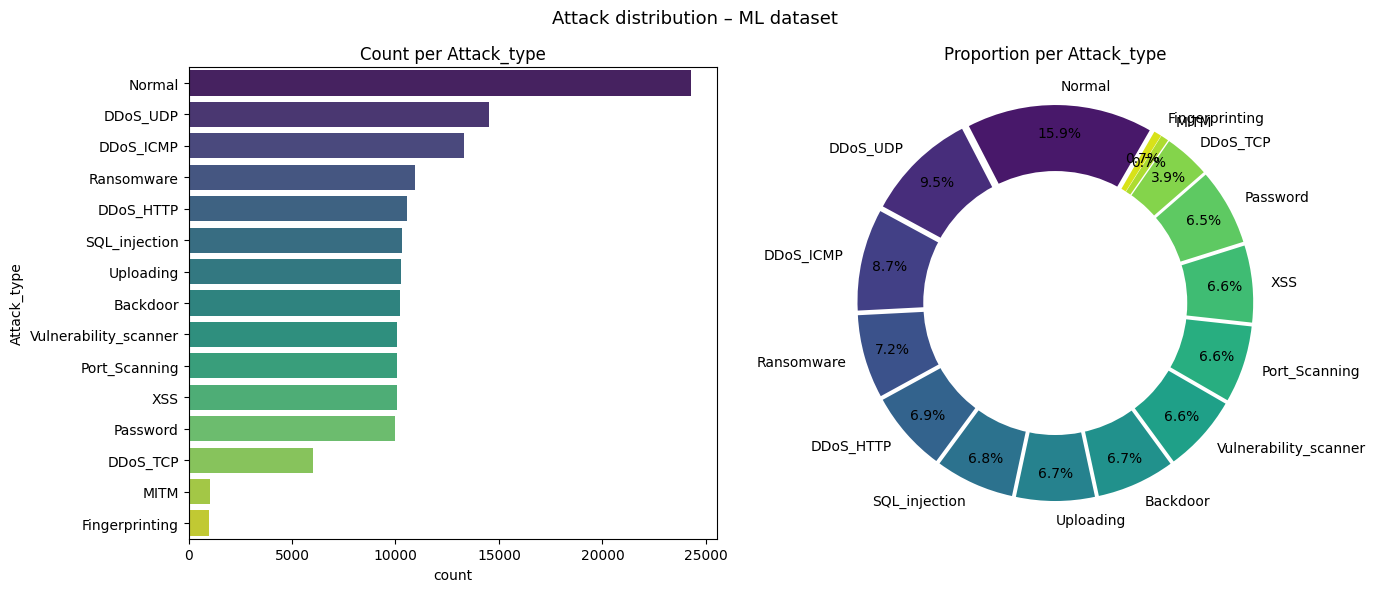

In [69]:
plot_label_distribution(df_ml,  "Attack_type", title_suffix="ML dataset")


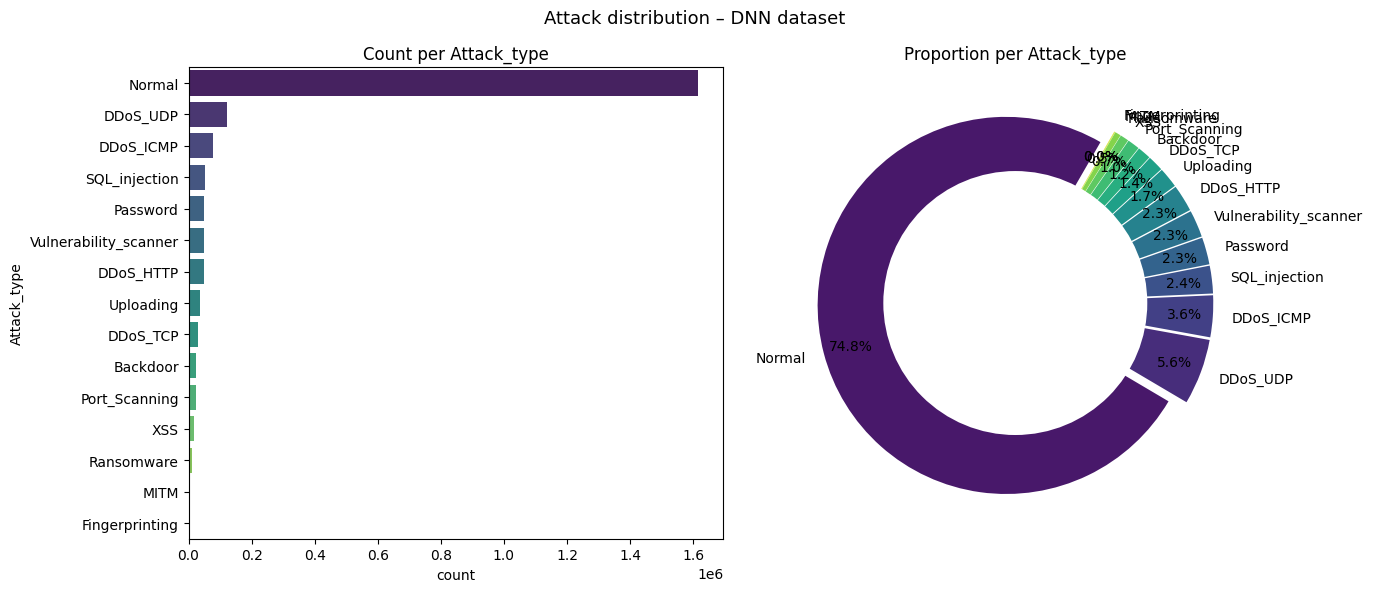

In [70]:
plot_label_distribution(df_dnn, "Attack_type", title_suffix="DNN dataset")


---
## 4 - Save Processed Datasets


In [71]:
import pickle

out_ml  = config['processed_path'] / "ML-EdgeIIoT-dataset.pkl"
out_dnn = config['processed_path'] / "DNN-EdgeIIoT-dataset.pkl"

df_ml.to_pickle(out_ml)
df_dnn.to_pickle(out_dnn)

print(f"Saved ML  → {out_ml}")
print(f"Saved DNN → {out_dnn}")


Saved ML  → /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/processed/ML-EdgeIIoT-dataset.pkl
Saved DNN → /home/uo294319/ML-NIDS-IIoT/data/edge_iiot/processed/DNN-EdgeIIoT-dataset.pkl
